[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Sentiment Analysis Using Recurrent Neural Networks

In this notebook we use an LSTM to classify the sentiment of the IMDb movie reviews we prepared in the previous notebook.  The architecture has three stages:

1. An **embedding layer** maps each token ID to a vector.
2. A **bidirectional LSTM** reads the sequence of token vectors and produces a fixed-length representation of the whole review.
3. A **linear layer** maps that representation to the two class scores ("negative", "positive").

The entire model — embeddings included — is trained end to end on the classification objective.

## From token IDs to vectors: the embedding layer

In our toy problems the alphabet had two tokens, and we fed the network one-hot vectors.  With a vocabulary of ~50,000 tokens, one-hot vectors are unwieldy: multiplying a one-hot vector by a weight matrix $\mathbf{W} \in \mathbb{R}^{|V| \times d}$ just *selects row $i$* of the matrix.  An `nn.Embedding` layer stores exactly this matrix and implements the multiplication as a lookup: token $i$ is represented by the learned $d$-dimensional vector in row $i$.

Mechanically, then, an embedding layer is just the input weight matrix made efficient.  But the switch away from one-hot inputs matters for a deeper, geometric reason.  One-hot vectors are all mutually orthogonal and equidistant: the representation of "great" is exactly as far from "excellent" as it is from "terrible", and the cosine similarity between any two distinct words is zero.  Nothing in the encoding can express that two words are related, and since each word interacts with the network only through its own private parameters, whatever the model learns about one word never transfers to another.

Embeddings address this directly.  All tokens are mapped into a shared continuous space of dimension $d \ll |V|$ in which distances and directions carry meaning — and because the rows of the embedding matrix are trainable parameters, that meaning is *learned*.  If "great" and "excellent" end up with nearby vectors, whatever the LSTM learns about sentences containing one automatically applies to sentences containing the other, even for word combinations never seen in training.  During training the network is free to arrange words in this space in whatever way helps predict sentiment; at the end of the notebook we will look at where words ended up — the geometry of the learned embedding is quite revealing.

In [1]:
import collections
import os
import re
import tarfile
import urllib.request

import numpy as np
import torch
from torch import nn
from matplotlib import pyplot as plt

Here is the contrast in a picture.  In one-hot space (left), every word is its own axis: the geometry is fixed in advance, identical for all vocabularies, and silent about which words are related.  In an embedding space (right), directions are learned, and the angles between words can come to reflect their relatedness.

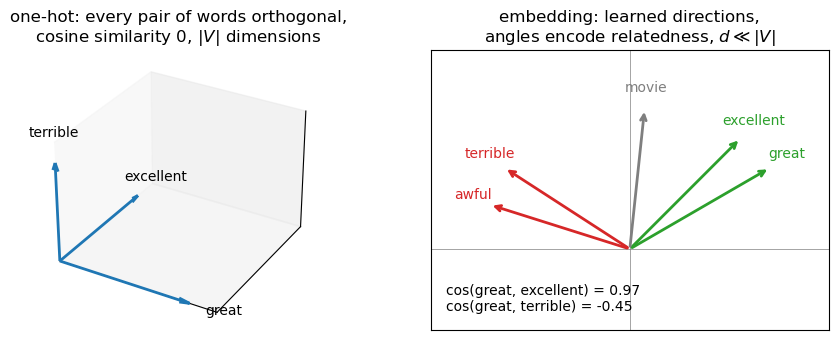

In [2]:
fig = plt.figure(figsize=(9.5, 3.5))

# left: one-hot -- every word is its own orthogonal axis
ax = fig.add_subplot(1, 2, 1, projection='3d')
for vec, word in zip(np.eye(3), ['great', 'excellent', 'terrible']):
    ax.quiver(0, 0, 0, *vec, arrow_length_ratio=0.08, color='C0', lw=2)
    ax.text(*(vec * 1.25), word, ha='center')
ax.set_xlim(0, 1.2); ax.set_ylim(0, 1.2); ax.set_zlim(0, 1.2)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_title('one-hot: every pair of words orthogonal,\n'
             'cosine similarity 0, $|V|$ dimensions')

# right: embedding -- directions are learned and angles carry meaning
ax = fig.add_subplot(1, 2, 2)
vecs = {'great': (0.95, 0.55), 'excellent': (0.75, 0.75),
        'terrible': (-0.85, 0.55), 'awful': (-0.95, 0.30),
        'movie': (0.10, 0.95)}
colors = {'great': 'C2', 'excellent': 'C2',
          'terrible': 'C3', 'awful': 'C3', 'movie': 'C7'}
for word, (x, y) in vecs.items():
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[word], lw=2))
    ax.text(x * 1.12, y * 1.12, word, ha='center', color=colors[word])

def cosine(a, b):
    a, b = np.array(vecs[a]), np.array(vecs[b])
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

ax.text(-1.25, -0.42,
        f"cos(great, excellent) = {cosine('great', 'excellent'):.2f}\n"
        f"cos(great, terrible) = {cosine('great', 'terrible'):.2f}",
        fontsize=10)
ax.set_xlim(-1.35, 1.35); ax.set_ylim(-0.55, 1.35)
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('embedding: learned directions,\n'
             'angles encode relatedness, $d \\ll |V|$')
plt.tight_layout();

## Loading the data

The following cell condenses the pipeline developed in the previous notebook: download, tokenize, build a vocabulary, truncate/pad to 500 tokens, and wrap everything in data iterators.

In [3]:
def download_imdb(data_dir='../data'):
    """Download and extract the IMDb review dataset."""
    # a fast mirror of https://ai.stanford.edu/~amaas/data/sentiment/
    url = 'https://d2l-data.s3-accelerate.amazonaws.com/aclImdb_v1.tar.gz'
    os.makedirs(data_dir, exist_ok=True)
    archive = os.path.join(data_dir, 'aclImdb_v1.tar.gz')
    if not os.path.exists(archive):
        print('downloading', url, '...')
        urllib.request.urlretrieve(url, archive)
    extracted = os.path.join(data_dir, 'aclImdb')
    if not os.path.exists(extracted):
        print('extracting ...')
        with tarfile.open(archive) as tar:
            tar.extractall(data_dir)
    return extracted

def read_imdb(data_dir, is_train):
    """Read the IMDb review dataset text sequences and labels."""
    data, labels = [], []
    for label in ('pos', 'neg'):
        folder_name = os.path.join(data_dir, 'train' if is_train else 'test',
                                   label)
        for file in os.listdir(folder_name):
            with open(os.path.join(folder_name, file), 'rb') as f:
                data.append(f.read().decode('utf-8').replace('\n', ''))
                labels.append(1 if label == 'pos' else 0)
    return data, labels

def tokenize(text):
    """Split a review into a list of lowercased word tokens."""
    text = text.replace('<br />', ' ').lower()
    return re.findall(r"[a-z0-9']+", text)

class Vocab:
    """A mapping between word tokens and integer indices."""
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        counter = collections.Counter(tok for line in tokens for tok in line)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens + [
            tok for tok, freq in self.token_freqs if freq >= min_freq]
        self.token_to_idx = {tok: idx
                             for idx, tok in enumerate(self.idx_to_token)}
    def __len__(self):
        return len(self.idx_to_token)
    def __getitem__(self, tokens):
        if isinstance(tokens, (list, tuple)):
            return [self[tok] for tok in tokens]
        return self.token_to_idx.get(tokens, self.unk)
    def to_tokens(self, indices):
        if hasattr(indices, '__len__'):
            return [self.idx_to_token[int(i)] for i in indices]
        return self.idx_to_token[int(indices)]
    @property
    def unk(self):
        return 0

def truncate_pad(line, num_steps, padding_token):
    """Truncate or pad a list of token IDs to exactly num_steps entries."""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

def load_data_imdb(batch_size, num_steps=500):
    """Return data iterators and the vocabulary of the IMDb review dataset."""
    data_dir = download_imdb()
    train_data = read_imdb(data_dir, True)
    test_data = read_imdb(data_dir, False)
    train_tokens = [tokenize(review) for review in train_data[0]]
    test_tokens = [tokenize(review) for review in test_data[0]]
    vocab = Vocab(train_tokens, min_freq=5, reserved_tokens=['<pad>'])
    train_features = torch.tensor([
        truncate_pad(vocab[line], num_steps, vocab['<pad>'])
        for line in train_tokens])
    test_features = torch.tensor([
        truncate_pad(vocab[line], num_steps, vocab['<pad>'])
        for line in test_tokens])
    train_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_features,
                                       torch.tensor(train_data[1])),
        batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(test_features,
                                       torch.tensor(test_data[1])),
        batch_size, shuffle=False)
    return train_iter, test_iter, vocab

batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

In [4]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


## Representing text with RNNs

In text classification tasks, such as sentiment analysis, a varying-length text sequence must be transformed into a fixed-length category.  In the following `BiRNN` class, each token of a text sequence gets its individual representation via the embedding layer (`self.embedding`), and then the entire sequence is encoded by a bidirectional LSTM (`self.encoder`).  More concretely, the hidden states (at the last layer) of the bidirectional LSTM at both the initial and final time steps are concatenated as the representation of the text sequence.  (Recall why both ends are informative: the forward chain's final state has read the whole review left to right, and the backward chain's state at the initial time step has read it right to left.)  This single text representation is then transformed into output categories by a fully connected layer (`self.decoder`) with two outputs ("positive" and "negative").

The overall recipe is the same as in our toy problems: a recurrent network turns the varying-length sequence into a fixed-length vector, and a linear layer reads the class out of that vector.  Three things are new here: an embedding layer replaces the one-hot encoding at the input; the recurrent network is larger — a two-layer bidirectional LSTM; and the sequence representation is read out from both ends of the sequence rather than from the final state alone.

A note on the decoder's input dimension, `4 * num_hiddens`, since intuition may suggest a factor of 2 for the two directions.  At every time step, a bidirectional LSTM outputs the *concatenation* of the forward and backward hidden states, so each entry of `outputs` already has `2 * num_hiddens` components.  We then concatenate the outputs at *two* time steps — the initial and the final — giving $2 \text{ (directions)} \times 2 \text{ (positions)} = 4$ times `num_hiddens`.  Why those two positions?  Each end of the sequence is fully informative for only one direction: at the final step the forward chain has read the entire review while the backward chain has seen only the last token; at the initial step the roles are reversed.  Taking both ends ensures the classifier sees a complete pass over the review in each direction.

In [5]:
class BiRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens,
                 num_layers, **kwargs):
        super(BiRNN, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # Set `bidirectional` to True to get a bidirectional RNN
        self.encoder = nn.LSTM(embed_size, num_hiddens, num_layers=num_layers,
                               bidirectional=True)
        # 4 * num_hiddens: 2 directions x 2 read-out positions (first and
        # last time step), each contributing num_hiddens values
        self.decoder = nn.Linear(4 * num_hiddens, 2)

    def forward(self, inputs):
        # The shape of `inputs` is (batch size, no. of time steps). Because
        # LSTM requires its input's first dimension to be the temporal
        # dimension, the input is transposed before obtaining token
        # representations. The output shape is (no. of time steps, batch size,
        # word vector dimension)
        embeddings = self.embedding(inputs.T)
        # Returns hidden states of the last hidden layer at different time
        # steps. The shape of `outputs` is (no. of time steps, batch size,
        # 2 * no. of hidden units)
        outputs, _ = self.encoder(embeddings)
        # Concatenate the hidden states at the initial and final time steps as
        # the input of the fully connected layer. Its shape is (batch size,
        # 4 * no. of hidden units)
        encoding = torch.cat((outputs[0], outputs[-1]), dim=1)
        outs = self.decoder(encoding)
        return outs

Let's construct a bidirectional LSTM with two hidden layers to represent single text for sentiment analysis.  The embedding layer is initialized randomly and trained together with the rest of the model.

In [6]:
embed_size = 100
num_hiddens = 100
num_layers = 2
model = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)
model = model.to(device)

In [7]:
def init_weights(module):
    if type(module) == nn.Linear:
        nn.init.xavier_uniform_(module.weight)
    if type(module) == nn.LSTM:
        for param in module._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(module._parameters[param])
model.apply(init_weights);

## Training and evaluating the model

Now we can train the bidirectional LSTM for sentiment analysis.

In [8]:
def accuracy(Y_hat, Y):
    """Fraction of correct predictions."""
    preds = Y_hat.argmax(dim=1).type(Y.dtype)
    return (preds == Y).float().mean()

In [9]:
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [10]:
epochs = 10
# overall loss value for each epoch:
loss_train = []
loss_valid = []
accuracy_valid = []
for epoch in range(epochs):
    model.train()
    loss_values = []  # loss values for each batch
    for batch_X, batch_y in train_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train.append(np.mean(loss_values))
    model.eval()
    loss_values = []
    accuracy_values = []
    for batch_X, batch_y in test_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        with torch.no_grad():
            preds = model(batch_X)
            loss = loss_fn(preds, batch_y)
            loss_values.append(loss.item())
            accuracy_values.append(accuracy(preds, batch_y).item())
    loss_valid.append(np.mean(loss_values))
    accuracy_valid.append(np.mean(accuracy_values))
    print(f'epoch {epoch + 1:2d}  train loss {loss_train[-1]:.3f}  '
          f'val loss {loss_valid[-1]:.3f}  '
          f'val accuracy {accuracy_valid[-1]:.3f}')

epoch  1  train loss 0.636  val loss 0.641  val accuracy 0.692
epoch  2  train loss 0.524  val loss 0.451  val accuracy 0.777
epoch  3  train loss 0.365  val loss 0.337  val accuracy 0.852
epoch  4  train loss 0.234  val loss 0.320  val accuracy 0.872
epoch  5  train loss 0.164  val loss 0.318  val accuracy 0.872
epoch  6  train loss 0.115  val loss 0.391  val accuracy 0.873
epoch  7  train loss 0.081  val loss 0.377  val accuracy 0.874
epoch  8  train loss 0.052  val loss 0.471  val accuracy 0.872
epoch  9  train loss 0.034  val loss 0.532  val accuracy 0.870
epoch 10  train loss 0.031  val loss 0.508  val accuracy 0.875


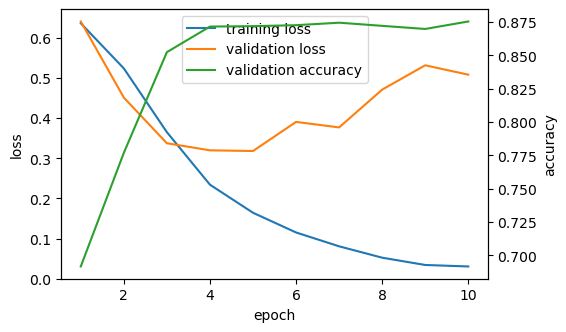

In [11]:
fig, ax1 = plt.subplots(figsize=(5.5, 3.5))
epochs_range = range(1, len(loss_train) + 1)
ax1.plot(epochs_range, loss_train, color='C0', label='training loss')
ax1.plot(epochs_range, loss_valid, color='C1', label='validation loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax2 = ax1.twinx()
ax2.plot(epochs_range, accuracy_valid, color='C2',
         label='validation accuracy')
ax2.set_ylabel('accuracy')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2);

We define the following function to predict the sentiment of a text sequence using the trained model:

In [12]:
def predict_sentiment(net, vocab, sequence):
    """Predict the sentiment of a text sequence."""
    sequence = torch.tensor(vocab[tokenize(sequence)], device=device)
    label = torch.argmax(net(sequence.reshape(1, -1)), dim=1)
    return 'positive' if label == 1 else 'negative' 

Finally, let's use the trained model to predict the sentiment for some simple sentences.

In [13]:
predict_sentiment(model, vocab, 'this movie is so great')

'positive'

In [14]:
predict_sentiment(model, vocab, 'this movie is so bad')

'negative'

In [15]:
predict_sentiment(model, vocab, 'this movie is not bad at all')

'negative'

In [16]:
predict_sentiment(model, vocab, 'this movie is mediocre')

'negative'

### How big is the model?

Let's check the size of the model, i.e. number of parameters and how each component of the model contributes to the parameter count:

In [17]:
# named_parameters() pairs each parameter tensor with the dotted path of
# the module that owns it - a good way to see the contribution of each layer
for name, p in model.named_parameters():
    print(f'{name:50s} {str(tuple(p.shape)):>15s} {p.numel():>12,d}')
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'{"total":50s} {"":15s} {total:>12,d}')

embedding.weight                                      (30563, 100)    3,056,300
encoder.weight_ih_l0                                    (400, 100)       40,000
encoder.weight_hh_l0                                    (400, 100)       40,000
encoder.bias_ih_l0                                          (400,)          400
encoder.bias_hh_l0                                          (400,)          400
encoder.weight_ih_l0_reverse                            (400, 100)       40,000
encoder.weight_hh_l0_reverse                            (400, 100)       40,000
encoder.bias_ih_l0_reverse                                  (400,)          400
encoder.bias_hh_l0_reverse                                  (400,)          400
encoder.weight_ih_l1                                    (400, 200)       80,000
encoder.weight_hh_l1                                    (400, 100)       40,000
encoder.bias_ih_l1                                          (400,)          400
encoder.bias_hh_l1                      

## A reality check: run the simple baseline

The bidirectional LSTM works — the predictions above are sensible and the accuracy curve climbed into a respectable range.  Before congratulating ourselves, though, there is a discipline every practitioner should keep: **run the simplest reasonable model first, and make sure the complicated one actually beats it.**

The simplest reasonable model for text is a *bag of words*: represent each review by its TF-IDF-weighted word and bigram counts — no embeddings, no recurrence, word order almost entirely discarded — and fit a logistic regression.  Let's put it head to head with the LSTM we just trained, on the same reviews.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# the same reviews as raw text (bag-of-words needs words, not padded token IDs)
train_data = read_imdb(data_dir, is_train=True)
test_data = read_imdb(data_dir, is_train=False)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_data[0])   # fit on train only
X_test = vectorizer.transform(test_data[0])
baseline = LogisticRegression(C=10, max_iter=1000).fit(X_train, train_data[1])

print(f'bidirectional LSTM     test accuracy: {accuracy_valid[-1]:.3f}')
print(f'TF-IDF + logistic reg  test accuracy: '
      f'{baseline.score(X_test, test_data[1]):.3f}')

NameError: name 'data_dir' is not defined

The linear model on word counts comes out ahead of — or at least even with — the LSTM, and it trained in seconds, with no GPU, no embedding layer, and no notion of word order.  That is worth sitting with.  It does not mean recurrent networks are useless; it means *this task* is largely about which words appear, and for such a task a bag of words is already close to optimal.  Movie-review sentiment simply has little sequential structure for the LSTM to exploit that counting misses.

The lesson is methodological, and it runs through the rest of these notebooks: **a strong, simple baseline is the yardstick for whether added complexity earns its keep.**  It reframes what comes next — the CNN, the transformer, a pretrained BERT — as a genuine question rather than a foregone win: can any of them clearly clear this bar?  Hold onto that question as you go.

## What did the embedding layer learn?

The embedding layer started as random vectors.  The only training signal it ever received was "help predict the sentiment of reviews" — nobody told it anything about the meanings of words.  Let's see how it organized the vocabulary.

A standard way to compare embedding vectors is **cosine similarity**, the cosine of the angle between two vectors $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$:

$$\frac{\mathbf{x}^\top \mathbf{y}}{\|\mathbf{x}\| \, \|\mathbf{y}\|} \in [-1, 1].$$

For a few query words, we find the tokens with the most similar embedding vectors, restricting to the 10,000 most frequent tokens.  Alongside each neighbor we print how many times it occurs in the training corpus — keep an eye on those counts when interpreting the results.

In [ ]:
W = model.embedding.weight.detach().cpu()          # (vocab_size, embed_size)
W_norm = W / W.norm(dim=1, keepdim=True).clamp(min=1e-8)
freq = dict(vocab.token_freqs)                     # token -> corpus count

def nearest_neighbors(word, k=8, max_rank=10000):
    idx = vocab[word]
    if idx == vocab.unk:
        return f'"{word}" not in vocabulary'
    # vocab indices are ordered by corpus frequency, so the first max_rank
    # rows of the embedding matrix belong to the max_rank most common tokens;
    # slicing thus restricts the candidate neighbors to well-trained embeddings
    sims = W_norm[:max_rank] @ W_norm[idx]
    best = sims.topk(k + 1).indices.tolist()
    best = [i for i in best if i != idx][:k]  # exclude the query word itself
    return [(vocab.to_tokens(i), sims[i].item()) for i in best]

for word in ['great', 'terrible', 'boring', 'wonderful', 'waste']:
    print(f'{word}:')
    for tok, sim in nearest_neighbors(word):
        print(f'   {tok:15s} {sim:6.3f}   ({freq.get(tok, 0)} occurrences)')

The neighborhoods are a revealing mix.  Many neighbors are exactly what we would hope for: words that signal the same sentiment as the query.  But you will also find odd hits — proper names, or words with no evident connection to the query's meaning.  The occurrence counts printed alongside explain much of what is going on:

* An embedding vector receives a gradient update only when its token appears in a training batch.  A word with a few dozen occurrences gets a handful of noisy nudges and ends up not far from wherever random initialization put it, so its similarities to other words are largely accidental.  (A character name that shows up mainly in reviews of one widely panned film can genuinely drift toward "negative" territory, too.)
* Even for frequent words, the embedding encodes only what helps predict sentiment — not meaning.  A word that merely *co-occurs* with negative reviews can land near "terrible" without being a negative word itself; the classifier has no reason to care about the difference.
* By representation-learning standards, 25,000 reviews is a small corpus.  Embeddings trained on billions of tokens — which is exactly what word2vec and GloVe are — have far cleaner geometry.  This is a key motivation for *pretrained* embeddings (see exercise 4).

Try lowering `max_rank` to 2,000: restricting to well-trained, frequent tokens makes the neighbor lists noticeably cleaner.

The global structure is more robust than any individual neighbor list.  We can see it by projecting the embeddings of some hand-picked review words onto their first two principal components:

In [ ]:
pos_words = ['great', 'excellent', 'wonderful', 'amazing', 'superb',
             'perfect', 'brilliant', 'best', 'loved', 'fantastic']
neg_words = ['terrible', 'awful', 'horrible', 'worst', 'boring',
             'waste', 'bad', 'poorly', 'stupid', 'disappointing']
neutral_words = ['movie', 'film', 'actor', 'scene', 'director',
                 'story', 'character', 'watch', 'plot', 'music']

words = pos_words + neg_words + neutral_words
vecs = W[torch.tensor(vocab[words])]
vecs = vecs - vecs.mean(dim=0)
U, S, V = torch.linalg.svd(vecs, full_matrices=False)
proj = (vecs @ V[:2].T).numpy()

plt.figure(figsize=(7, 5.5))
colors = ['C2'] * len(pos_words) + ['C3'] * len(neg_words)          + ['C7'] * len(neutral_words)
plt.scatter(proj[:, 0], proj[:, 1], c=colors, s=12)
for (x, y), word in zip(proj, words):
    plt.annotate(word, (x, y), fontsize=9, xytext=(3, 3),
                 textcoords='offset points')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.title('learned embeddings: positive (green), negative (red), '
          'neutral (gray)');

Positive and negative words separate along a dominant direction — a "sentiment axis" — while the neutral, topical words sit in between.  A couple of observations worth dwelling on:

* This organization is a *by-product of classification training*.  Compare this with word embeddings trained on raw text (e.g., word2vec or GloVe): there, words are placed near each other when they appear in similar *contexts*, so "good" and "bad" — which are nearly interchangeable syntactically — often end up close together.  Our sentiment-trained embedding tears those apart, because separating them is precisely what the loss rewards.  The geometry of an embedding always reflects the objective that shaped it.
* The same lesson as the counting task, one level up: there, the hidden state learned to store a count because that was what the output needed; here, the embedding learned a sentiment axis because that is what the classifier needs.  **Representations are shaped by the task.**

## What makes RNNs slow

Training this model takes minutes per epoch on a laptop, and it is worth understanding exactly why — the answer explains much of the last decade of architecture design, and it is not simply "there are many operations."

**Where the work is.**  At every one of the 500 time steps, each LSTM cell computes its four gates, and each gate requires an input-to-hidden and a hidden-to-hidden matrix multiplication.  With 2 layers and 2 directions, that is four LSTM chains of 500 steps per review.  The embedding layer, despite holding the majority of the model's parameters, costs almost nothing: its forward pass is a table lookup.  (This is also why pretrained embeddings would not speed up training — their benefit is statistical, not computational.)

**Why hardware can't help more.**  The deeper problem is not the number of operations, but that the sequential structure of the computation does not support parallelism.  The recurrence $\mathbf{H}_t = f(\mathbf{X}_t, \mathbf{H}_{t-1})$ makes each step depend on the previous one, so the 500 steps must execute one after another — even though at training time the entire input sequence is sitting in memory, available all at once.  Each step is a small matrix multiplication (batch size by `num_hiddens`), far too small to keep a modern GPU busy, and there are 500 of them in a row for every direction of every layer.  An MLP or CNN with the same operation count runs much faster, because its work arrives as a few large matrix multiplications that use the hardware fully.  The serialization is imposed purely by the architecture, not by the task.

Practically, the cheapest speedup here is to shorten the sequences: we padded every review to 500 tokens, but the histogram in the dataset notebook shows most reviews are far shorter, so much of the computation is spent processing `<pad>` tokens.  Try `num_steps=200`.  (PyTorch's `pack_padded_sequence` is the principled fix — it lets the LSTM skip padding entirely.)

**The way out.**  What we would like is an architecture that, like the RNN, lets each position's representation depend on the entire sequence — but computes all positions *in parallel*, as a few large matrix operations.  That is precisely what **attention** provides, and it is the subject of the next module.  The trade-offs, as we will see: attention has no built-in notion of token order (it must be added back in), and its cost grows quadratically with sequence length rather than linearly.

## Summary

* An embedding layer is a trainable lookup table mapping token IDs to vectors — equivalent to multiplying a one-hot vector by a weight matrix, but efficient.  It can be trained end to end as part of a classifier.
* A bidirectional LSTM encodes a varying-length token sequence into a fixed-length vector (here, the concatenated hidden states at both ends of the sequence), which a linear layer maps to class scores.
* The learned embedding organizes the vocabulary according to the training objective: for sentiment classification, frequent words arrange themselves along a sentiment direction, regardless of topic or syntax.  Rare words receive too few gradient updates for their positions to be meaningful — one reason to initialize from embeddings pretrained on a large corpus.

## Exercises

1. Increase the number of training epochs.  Watch the gap between training and validation loss: when does the model start to overfit?  The embedding layer holds most of the model's parameters — how might that contribute?
2. The model misclassifies "this movie is not bad at all" for some random seeds.  Why is negation hard for this architecture?  Try a few more negated sentences and inspect the results.
3. Instead of concatenating the encodings at the first and last time steps, average the LSTM outputs over all time steps.  Does the accuracy change?
4. One remedy for overfitting embeddings on a modest dataset is to initialize them from vectors pretrained on a large corpus (e.g., word2vec or GloVe) instead of random values — they can then be fine-tuned or frozen.  Load 100-dimensional GloVe vectors into `model.embedding`, retrain, and compare accuracy and training speed.  After fine-tuning on sentiment, check the nearest neighbors of "great" again: how did they change?
5. Quantify the frequency effect on embedding quality: plot the norm of each embedding vector against the corpus frequency of its token (log scale).  What do you observe, and how does it relate to the number of gradient updates each row receives?